In [1]:
# ============================================
# 1: Import Libraries
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, roc_auc_score)

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
print("Libraries imported successfully")

Libraries imported successfully


In [2]:
# ============================================
# 2: Load Dataset
# ============================================
df = pd.read_csv("DataCoSupplyChainDataset.csv", encoding='latin-1')
print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (180519, 53)


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [3]:
# ============================================
# 3: Basic Information
# ============================================
print("Dataset Info:")
print(df.info())

print("\nStatistical Summary:")
df.describe()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Email                 180519 non-null  object 
 12  Customer Fname  

,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Category Id,Customer Id,Customer Zipcode,Department Id,Latitude,...,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Price,Product Status
count,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180516.000000,180519.000000,180519.000000,...,180519.000000,180519.000000,180519.000000,180519.000000,24840.000000,180519.000000,180519.000000,0.0,180519.000000,180519.0
mean,3.497654,2.931847,21.974989,183.107609,0.548291,31.851451,6691.379495,35921.126914,5.443460,29.719955,...,2.127638,203.772096,183.107609,21.974989,55426.132327,692.509764,31.851451,NaN,141.232550,0.0
std,1.623722,1.374449,104.433526,120.043670,0.497664,15.640064,4162.918106,37542.461122,1.629246,9.813646,...,1.453451,132.273077,120.043670,104.433526,31919.279101,336.446807,15.640064,NaN,139.732492,0.0
min,0.000000,0.000000,-4274.979980,7.490000,0.000000,2.000000,1.000000,603.000000,2.000000,-33.937553,...,1.000000,9.990000,7.490000,-4274.979980,1040.000000,19.000000,2.000000,NaN,9.990000,0.0
25%,2.000000,2.000000,7.000000,104.379997,0.000000,18.000000,3258.500000,725.000000,4.000000,18.265432,...,1.000000,119.980003,104.379997,7.000000,23464.000000,403.000000,18.000000,NaN,50.000000,0.0
50%,3.000000,4.000000,31.520000,163.990005,1.000000,29.000000,6457.000000,19380.000000,5.000000,33.144863,...,1.000000,199.919998,163.990005,31.520000,59405.000000,627.000000,29.000000,NaN,59.990002,0.0
75%,5.000000,4.000000,64.800003,247.399994,1.000000,45.000000,9779.000000,78207.000000,7.000000,39.279617,...,3.000000,299.950012,247.399994,64.800003,90008.000000,1004.000000,45.000000,NaN,199.990005,0.0
max,6.000000,4.000000,911.799988,1939.989990,1.000000,76.000000,20757.000000,99205.000000,12.000000,48.781933,...,5.000000,1999.989990,1939.989990,911.799988,99301.000000,1363.000000,76.000000,NaN,1999.989990,0.0


In [4]:
# ============================================
# 4: Missing Value Analysis
# ============================================
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Missing values per column:\n", missing)

Missing values per column:
 Product Description    180519
Order Zipcode          155679
Customer Lname              8
Customer Zipcode            3
dtype: int64


In [5]:
# ============================================
# 5: Data Cleaning
# ============================================
# Drop columns that are not useful or contain personal information
drop_cols = ['Customer Email', 'Customer Password', 'Customer Fname',
             'Customer Lname', 'Customer Street', 'Customer Zipcode',
             'Product Description', 'Product Image', 'Order Zipcode']

df = df.drop(columns=[c for c in drop_cols if c in df.columns])

# Convert dates
df['order date (DateOrders)'] = pd.to_datetime(df['order date (DateOrders)'])
df['shipping date (DateOrders)'] = pd.to_datetime(df['shipping date (DateOrders)'])

# Remove duplicates
df = df.drop_duplicates()

print("After cleaning, shape:", df.shape)
df.head()

After cleaning, shape: (180519, 44)


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Region,Order State,Order Status,Product Card Id,Product Category Id,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,Southeast Asia,Java Occidental,COMPLETE,1360,73,Smart watch,327.75,0,2018-02-03 22:56:00,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,South Asia,Rajastán,PENDING,1360,73,Smart watch,327.75,0,2018-01-18 12:27:00,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,South Asia,Rajastán,CLOSED,1360,73,Smart watch,327.75,0,2018-01-17 12:06:00,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,Oceania,Queensland,COMPLETE,1360,73,Smart watch,327.75,0,2018-01-16 11:45:00,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,Oceania,Queensland,PENDING_PAYMENT,1360,73,Smart watch,327.75,0,2018-01-15 11:24:00,Standard Class


In [6]:
# ============================================
# 6: Create New Features
# ============================================
# Delivery delay = actual days - scheduled days
df['Delivery_Delay'] = df['Days for shipping (real)'] - df['Days for shipment (scheduled)']

# Late delivery flag (1 = late, 0 = on time)
df['Late_Delivery'] = (df['Delivery_Delay'] > 0).astype(int)

# Time-based features
df['Order_Year']      = df['order date (DateOrders)'].dt.year
df['Order_Month']     = df['order date (DateOrders)'].dt.month
df['Order_DayOfWeek'] = df['order date (DateOrders)'].dt.dayofweek

# Profit margin (%)
df['Profit_Margin_%'] = (df['Order Profit Per Order'] / df['Sales']) * 100

print("New features created:")
df[['Delivery_Delay', 'Late_Delivery', 'Order_Month', 'Profit_Margin_%']].head()

New features created:


,Delivery_Delay,Late_Delivery,Order_Month,Profit_Margin_%
0,-1,0,1,27.841342
1,1,1,1,-75.999999
2,0,0,1,-75.600305
3,-1,0,1,6.974829
4,-2,0,1,40.948896


In [7]:
# ============================================
# 7: Business KPI Summary
# ============================================
total_orders   = len(df)
late_rate      = df['Late_Delivery'].mean() * 100
avg_delay      = df['Delivery_Delay'].mean()
total_sales    = df['Sales'].sum()
total_profit   = df['Order Profit Per Order'].sum()
avg_margin     = df['Profit_Margin_%'].mean()

print("=" * 50)
print("SUPPLY CHAIN KPI DASHBOARD")
print("=" * 50)
print(f"Total Orders          : {total_orders:,}")
print(f"Late Delivery Rate    : {late_rate:.2f} %")
print(f"Average Delay (days)  : {avg_delay:.2f}")
print(f"Total Sales           : $ {total_sales:,.0f}")
print(f"Total Profit          : $ {total_profit:,.0f}")
print(f"Avg Profit Margin (%) : {avg_margin:.2f}")
print("=" * 50)

SUPPLY CHAIN KPI DASHBOARD
Total Orders          : 180,519
Late Delivery Rate    : 57.28 %
Average Delay (days)  : 0.57
Total Sales           : $ 36,784,735
Total Profit          : $ 3,966,903
Avg Profit Margin (%) : 10.83


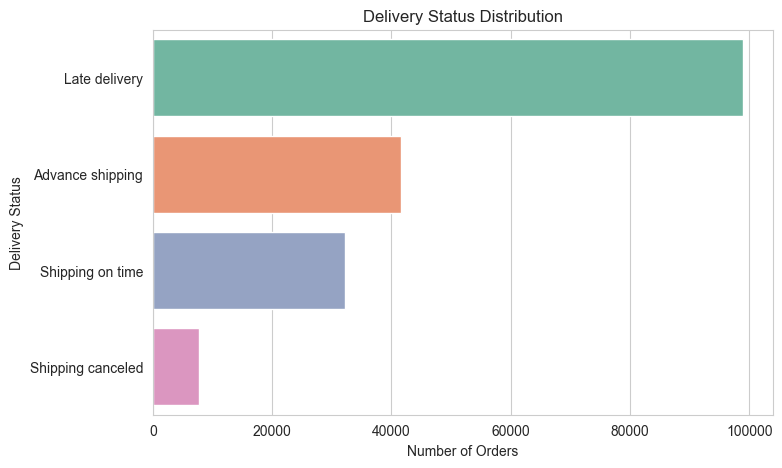

In [8]:
# ============================================
# 8: Delivery Status Visualization
# ============================================
plt.figure(figsize=(8, 5))
sns.countplot(data=df, y='Delivery Status',
              order=df['Delivery Status'].value_counts().index,
              palette='Set2')
plt.title("Delivery Status Distribution")
plt.xlabel("Number of Orders")
plt.show()

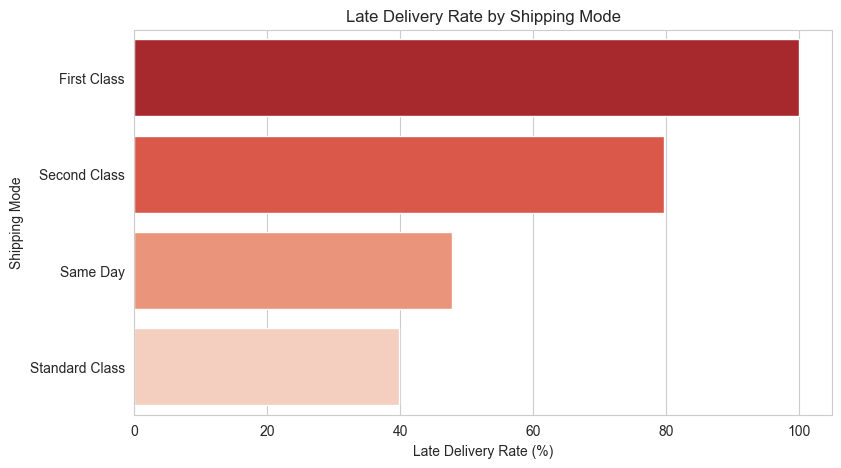

Worst shipping mode: First Class (100.0% late)


In [9]:
# ============================================
# 9: Bottleneck #1 — Shipping Mode
# ============================================
ship_mode = df.groupby('Shipping Mode')['Late_Delivery'].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(9, 5))
sns.barplot(x=ship_mode.values, y=ship_mode.index, palette='Reds_r')
plt.title("Late Delivery Rate by Shipping Mode")
plt.xlabel("Late Delivery Rate (%)")
plt.show()

print("Worst shipping mode:", ship_mode.idxmax(), f"({ship_mode.max():.1f}% late)")

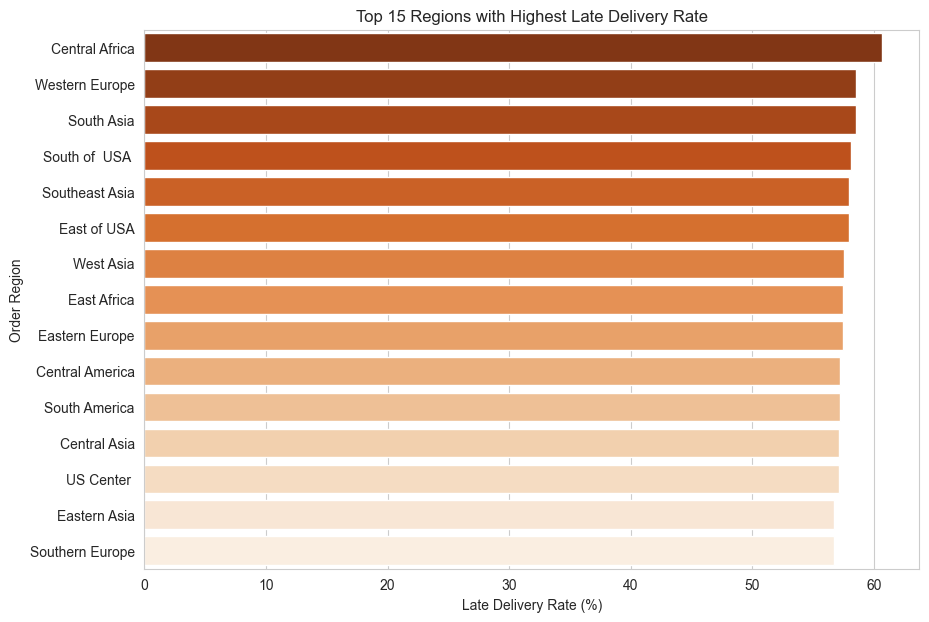

In [10]:
# ============================================
# 10: Bottleneck #2 — Regions
# ============================================
region_late = df.groupby('Order Region')['Late_Delivery'].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(10, 7))
sns.barplot(x=region_late.head(15).values,
            y=region_late.head(15).index, palette='Oranges_r')
plt.title("Top 15 Regions with Highest Late Delivery Rate")
plt.xlabel("Late Delivery Rate (%)")
plt.show()

In [11]:
# ============================================
# 11: Bottleneck #3 — Product Categories
# ============================================
cat_late = df.groupby('Category Name').agg(
    late_rate   = ('Late_Delivery', 'mean'),
    avg_profit  = ('Order Profit Per Order', 'mean'),
    orders      = ('Order Id', 'count')
).sort_values('late_rate', ascending=False)

cat_late['late_rate'] = cat_late['late_rate'] * 100
print("Top 10 categories by late delivery:")
cat_late.head(10)

Top 10 categories by late delivery:


,late_rate,avg_profit,orders
Category Name,,,
Golf Bags & Carts,68.852459,29.673279,61
Lacrosse,62.099125,12.723878,343
Cameras,61.993243,51.165203,592
Pet Supplies,61.382114,7.295244,492
Sporting Goods,59.943978,35.066135,357
Basketball,59.701493,27.547313,67
Fitness Accessories,59.546926,17.017443,309
Crafts,59.504132,52.750351,484
Strength Training,59.459459,2.993785,111


         avg_profit  total_profit  orders
On-Time   22.496873  1.734936e+06   77119
Late      21.585751  2.231967e+06  103400


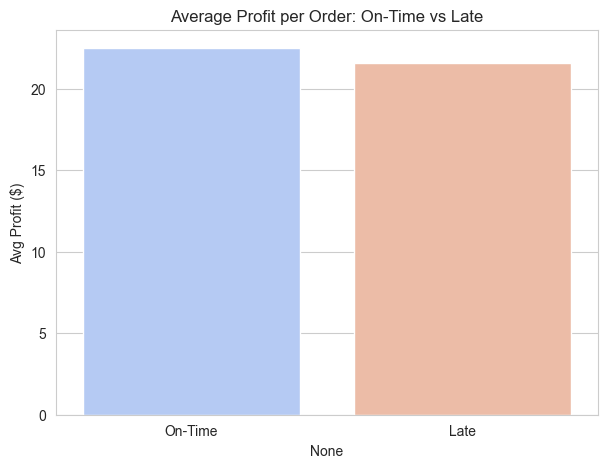

In [12]:
# ============================================
# 12: Profitability Impact of Late Delivery
# ============================================
profit_compare = df.groupby('Late_Delivery').agg(
    avg_profit   = ('Order Profit Per Order', 'mean'),
    total_profit = ('Order Profit Per Order', 'sum'),
    orders       = ('Order Id', 'count')
)
profit_compare.index = ['On-Time', 'Late']
print(profit_compare)

plt.figure(figsize=(7, 5))
sns.barplot(x=profit_compare.index, y=profit_compare['avg_profit'], palette='coolwarm')
plt.title("Average Profit per Order: On-Time vs Late")
plt.ylabel("Avg Profit ($)")
plt.show()

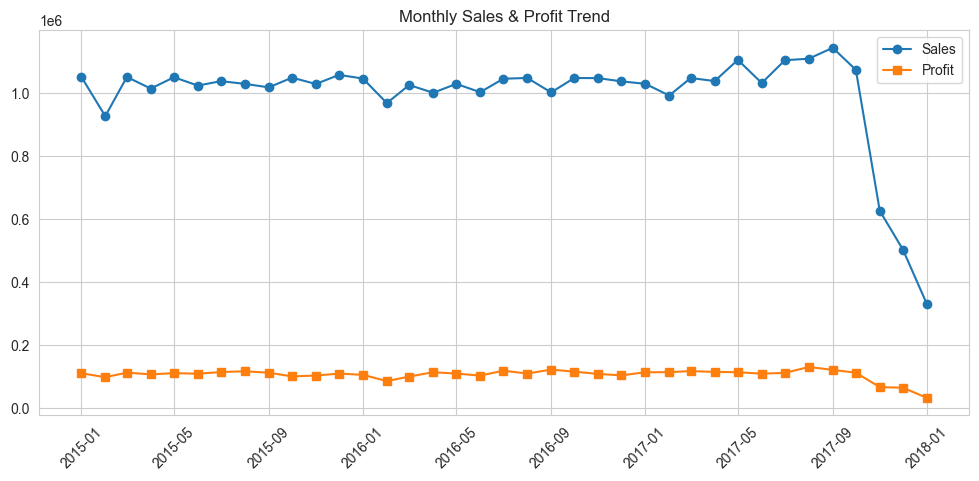

In [13]:
# ============================================
# 13: Monthly Sales Trend
# ============================================
monthly = df.groupby([df['order date (DateOrders)'].dt.to_period('M')])\
            .agg(sales=('Sales','sum'), profit=('Order Profit Per Order','sum'))
monthly.index = monthly.index.to_timestamp()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly.index, monthly['sales'],  label='Sales',  marker='o')
ax.plot(monthly.index, monthly['profit'], label='Profit', marker='s')
ax.set_title("Monthly Sales & Profit Trend")
ax.legend()
plt.xticks(rotation=45)
plt.show()

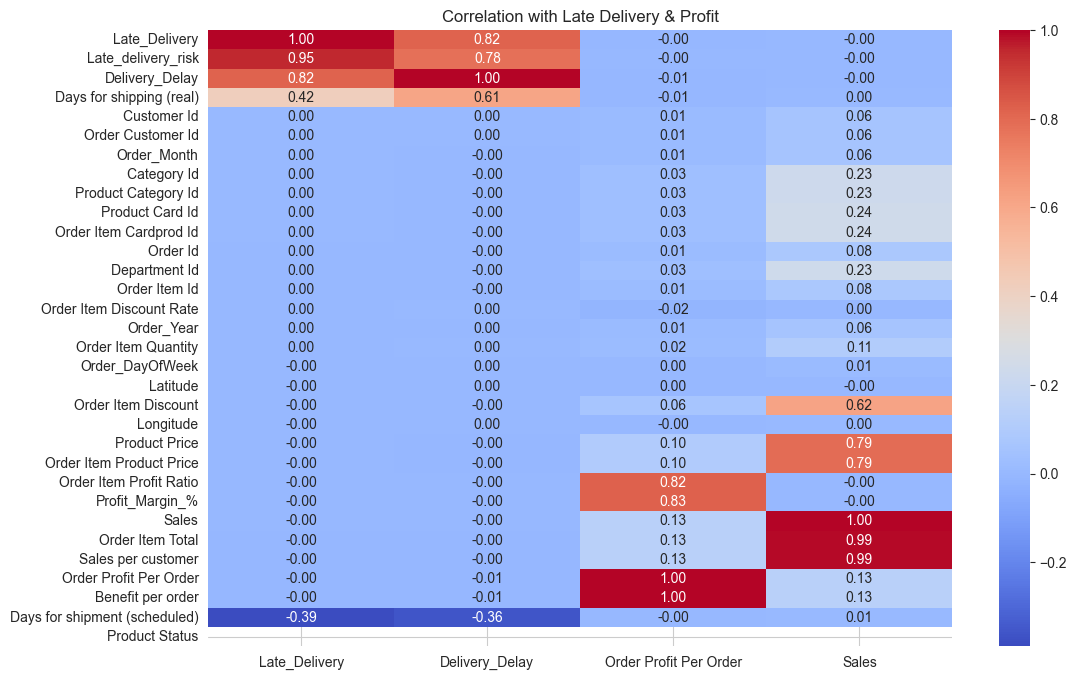

In [14]:
# ============================================
# 14: Correlation Heatmap of Numeric Features
# ============================================
num_df = df.select_dtypes(include=np.number)
corr = num_df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr[['Late_Delivery','Delivery_Delay',
                  'Order Profit Per Order','Sales']].sort_values(
            by='Late_Delivery', ascending=False),
            annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation with Late Delivery & Profit")
plt.show()

In [15]:
# ============================================
# 15: Build Feature Matrix
# ============================================
features = ['Type', 'Days for shipment (scheduled)', 'Benefit per order',
            'Sales per customer', 'Category Id', 'Customer Segment',
            'Department Id', 'Market', 'Order Region', 'Order Country',
            'Order Item Quantity', 'Order Item Total', 'Product Price',
            'Shipping Mode', 'Order_Month', 'Order_DayOfWeek']

X = df[features].copy()
y = df['Late_Delivery']

# Encode categorical columns
encoders = {}
for col in X.select_dtypes(include='object').columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    encoders[col] = le

print("Features prepared. Shape:", X.shape)
X.head()

Features prepared. Shape: (180519, 16)


,Type,Days for shipment (scheduled),Benefit per order,Sales per customer,Category Id,Customer Segment,Department Id,Market,Order Region,Order Country,Order Item Quantity,Order Item Total,Product Price,Shipping Mode,Order_Month,Order_DayOfWeek
0,1,4,91.250000,314.640015,73,0,2,3,15,70,1,314.640015,327.75,3,1,2
1,3,4,-249.089996,311.359985,73,0,2,3,13,69,1,311.359985,327.75,3,1,5
2,0,4,-247.779999,309.720001,73,0,2,3,13,69,1,309.720001,327.75,3,1,5
3,1,4,22.860001,304.809998,73,2,2,3,11,8,1,304.809998,327.75,3,1,5
4,2,4,134.210007,298.250000,73,1,2,3,11,8,1,298.250000,327.75,3,1,5


In [16]:
# ============================================
# 16: Train-Test Split
# ============================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Train size:", X_train.shape)
print("Test  size:", X_test.shape)

Train size: (144415, 16)
Test  size: (36104, 16)


In [17]:
# ============================================
# 17: Train and Compare Models
# ============================================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree"      : DecisionTreeClassifier(max_depth=10, random_state=42),
    "Random Forest"      : RandomForestClassifier(n_estimators=150, max_depth=12,
                                                  random_state=42, n_jobs=-1)
}

results = {}
for name, mdl in models.items():
    mdl.fit(X_train, y_train)
    preds  = mdl.predict(X_test)
    proba  = mdl.predict_proba(X_test)[:, 1]
    acc    = accuracy_score(y_test, preds)
    auc    = roc_auc_score(y_test, proba)
    results[name] = {'accuracy': acc, 'roc_auc': auc, 'model': mdl}
    print(f"{name:25s} | Accuracy: {acc * 100:.4f}% | ROC-AUC: {auc:.4f}")

Logistic Regression       | Accuracy: 69.2389% | ROC-AUC: 0.7262
Decision Tree             | Accuracy: 70.0116% | ROC-AUC: 0.7497
Random Forest             | Accuracy: 70.1806% | ROC-AUC: 0.7603


Best Model: Random Forest

Classification Report:
               precision    recall  f1-score   support

           0       0.60      0.88      0.72     15424
           1       0.87      0.57      0.68     20680

    accuracy                           0.70     36104
   macro avg       0.74      0.73      0.70     36104
weighted avg       0.75      0.70      0.70     36104



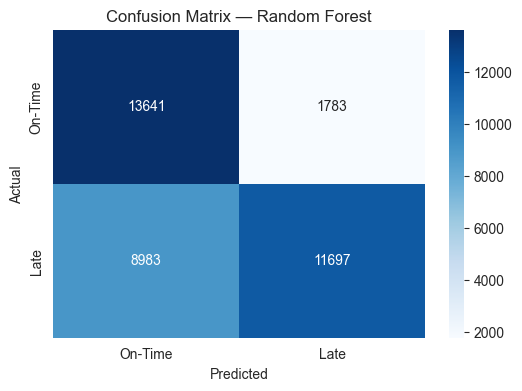

In [18]:
# ============================================
# 18: Detailed Evaluation of Best Model
# ============================================
best_name  = max(results, key=lambda k: results[k]['roc_auc'])
best_model = results[best_name]['model']
print(f"Best Model: {best_name}")

y_pred = best_model.predict(X_test)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['On-Time', 'Late'],
            yticklabels=['On-Time', 'Late'])
plt.title(f"Confusion Matrix — {best_name}")
plt.ylabel("Actual"); plt.xlabel("Predicted")
plt.show()

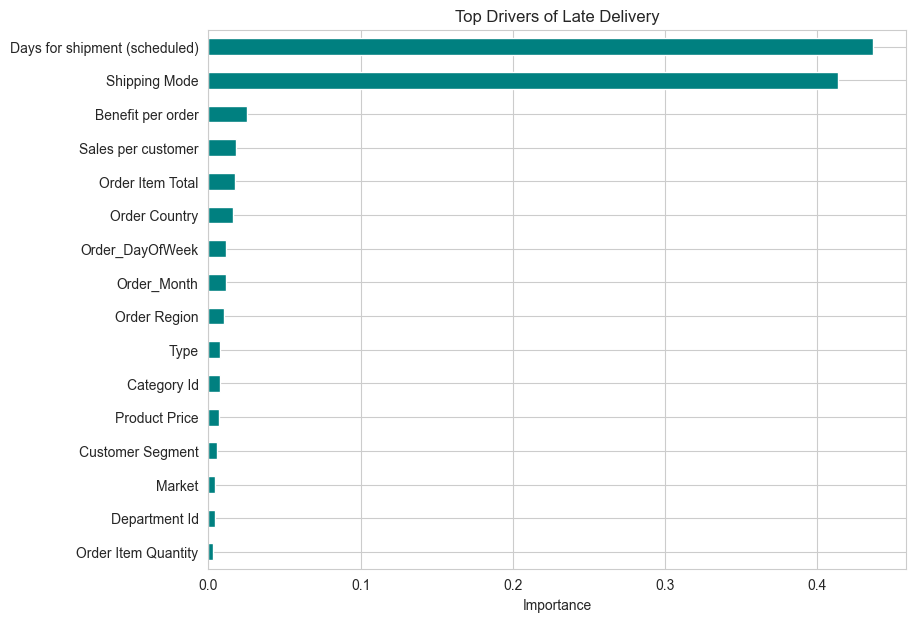

In [19]:
# ============================================
# 19: Feature Importance (Random Forest)
# ============================================
rf = results['Random Forest']['model']
imp = pd.Series(rf.feature_importances_, index=features)\
        .sort_values(ascending=True)

plt.figure(figsize=(9, 7))
imp.plot(kind='barh', color='teal')
plt.title("Top Drivers of Late Delivery")
plt.xlabel("Importance")
plt.show()

In [20]:
# ============================================
# 20: Best Shipping Mode per Region
# ============================================
rec = df.groupby(['Order Region', 'Shipping Mode']).agg(
    late_rate  = ('Late_Delivery', 'mean'),
    avg_profit = ('Order Profit Per Order', 'mean'),
    orders     = ('Order Id', 'count')
).reset_index()

# Pick the shipping mode with the LOWEST late delivery rate per region
best_modes = rec.loc[rec.groupby('Order Region')['late_rate'].idxmin()]
best_modes = best_modes.sort_values('late_rate')

print("Recommended Shipping Mode per Region (lowest late rate):")
best_modes.head(15)

Recommended Shipping Mode per Region (lowest late rate):


,Order Region,Shipping Mode,late_rate,avg_profit,orders
17,Central Asia,Same Day,0.203125,24.606250,64
9,Central Africa,Same Day,0.303797,31.510253,79
3,Canada,Standard Class,0.303819,25.847500,576
33,Eastern Europe,Same Day,0.359551,19.817640,178
7,Caribbean,Standard Class,0.372397,20.469393,5043
39,North Africa,Standard Class,0.377583,19.297867,1936
71,Southern Europe,Standard Class,0.383746,26.640526,5660
31,Eastern Asia,Standard Class,0.386893,21.277731,4425
73,US Center,Same Day,0.386997,16.055511,323
87,West of USA,Standard Class,0.387090,22.588611,4787


In [21]:
# ============================================
# 21: Predict Delay for a New Sample Order
# ============================================
sample_order = pd.DataFrame([{
    'Type'                          : 'DEBIT',
    'Days for shipment (scheduled)' : 2,
    'Benefit per order'             : 50,
    'Sales per customer'            : 200,
    'Category Id'                   : 45,
    'Customer Segment'              : 'Consumer',
    'Department Id'                 : 7,
    'Market'                        : 'LATAM',
    'Order Region'                  : 'Central America',
    'Order Country'                 : 'Mexico',
    'Order Item Quantity'           : 1,
    'Order Item Total'              : 199,
    'Product Price'                 : 199,
    'Shipping Mode'                 : 'Standard Class',
    'Order_Month'                   : 6,
    'Order_DayOfWeek'               : 3
}])

# Safe encoding function — handles unseen labels
def safe_encode(value, encoder):
    """Encode value if known, otherwise return -1."""
    value = str(value)
    if value in encoder.classes_:
        return encoder.transform([value])[0]
    else:
        print(f"Unseen label '{value}' — replaced with -1")
        return -1

# Apply safe encoding to each categorical column
for col, le in encoders.items():
    if col in sample_order.columns:
        sample_order[col] = sample_order[col].apply(lambda x: safe_encode(x, le))

# Make prediction
prob = best_model.predict_proba(sample_order)[0, 1]
decision = "HIGH RISK — Use faster shipping" if prob > 0.5 else "LOW RISK — Proceed"

print(f"\nDelay Probability : {prob:.2%}")
print(f"Recommendation    : {decision}")

Unseen label 'Mexico' — replaced with -1

Delay Probability : 52.63%
Recommendation    : HIGH RISK — Use faster shipping


In [22]:
# ============================================
# 22: Summary of Insights
# ============================================
print("=" * 60)
print("FINAL BUSINESS INSIGHTS")
print("=" * 60)
print(f"1. Overall Late Delivery Rate    : {late_rate:.2f}%")
print(f"2. Worst Shipping Mode           : {ship_mode.idxmax()} ({ship_mode.max():.1f}% late)")
print(f"3. Worst Region                  : {region_late.idxmax()} ({region_late.max():.1f}% late)")
print(f"4. Best Predictive Model         : {best_name} (ROC-AUC = {results[best_name]['roc_auc']:.3f})")
print(f"5. Total Profit Lost on Late Ord.: $ {df[df['Late_Delivery']==1]['Order Profit Per Order'].sum():,.0f}")
print("=" * 60)
print("\nRECOMMENDATIONS:")
print("• Upgrade shipping mode for high-risk regions")
print("• Allocate extra buffer days for problematic categories")
print("• Monitor predicted high-risk orders proactively")
print("• Use the recommendation table to optimize logistics")

FINAL BUSINESS INSIGHTS
1. Overall Late Delivery Rate    : 57.28%
2. Worst Shipping Mode           : First Class (100.0% late)
3. Worst Region                  : Central Africa (60.7% late)
4. Best Predictive Model         : Random Forest (ROC-AUC = 0.760)
5. Total Profit Lost on Late Ord.: $ 2,231,967

RECOMMENDATIONS:
• Upgrade shipping mode for high-risk regions
• Allocate extra buffer days for problematic categories
• Monitor predicted high-risk orders proactively
• Use the recommendation table to optimize logistics
